# Data Collection and Analysis
The first step in our project is to collect the necessary data for training and evaluating our seizure detection models. We will use the ["Epileptic Seizure Recognition" dataset](https://physionet.org/content/chbmit/1.0.0/), which contains EEG recordings from 23 patients (and ocassionally other signals that we will exclude from analysis). Each recording is labeled as either normal or status epilepticus, providing a basis for training and evaluating classification models. We will download the relevant files, including the summary files for each patient and the `SUBJECT-INFO.txt` file, which contains demographic and clinical information about the patients. This data will be essential for understanding the characteristics of the recordings and for selecting appropriate subsets for analysis.

In [107]:
import os
from pathlib import Path
cur_dir = Path(os.getcwd())
proj_dir = cur_dir.resolve().parent.parent
RAW_INFO_PATH = proj_dir / "data" / "raw" / "info"
RAW_RECORDS_PATH = proj_dir / "data" / "raw" / "records"

PATH_SAVE_PLOTS = proj_dir / 'doc' / 'src' / 'exploration'
SAVE = True


from utils.collection.collect import *
from utils.exploration.raw_data import *

## Data Information Retrieval
We retrieve the dataset information using the `SUBJECT-INFO.txt` file and the summary files for each patient. This information is organized into a DataFrame for easier analysis and visualization. We will analyze the distribution of seizures across patients, the duration of seizures, and other relevant clinical information to inform our data selection process.

In [108]:
if not os.path.exists(RAW_INFO_PATH):
    collect_info(RAW_INFO_PATH)
else:
    print('Data collected already...')

Data collected already...


In [109]:
df_info = make_info_df(RAW_INFO_PATH, save_csv=True, csv_path = RAW_INFO_PATH/"collected_info.csv")

[OK] DataFrame saved to C:\Users\aless\Desktop\EEG-epileptic-seizures-detection\data\raw\info\collected_info.csv


In [110]:
df_info

,subject,sampling_freq,num_seizures,seizure_durations,avg_seizure_dur,min_seizure_dur,max_seizure_dur,num_files,sex,age
0,chb01,256,7,"[40.0, 27.0, 40.0, 51.0, 90.0, 93.0, 101.0]",63.142857,27.0,101.0,42,F,11
1,chb02,256,3,"[82.0, 81.0, 9.0]",57.333333,9.0,82.0,36,M,11
2,chb03,256,7,"[52.0, 65.0, 69.0, 52.0, 47.0, 64.0, 53.0]",57.428571,47.0,69.0,38,F,14
3,chb04,256,4,"[49.0, 111.0, 102.0, 116.0]",94.500000,49.0,116.0,42,M,22
4,chb05,256,5,"[115.0, 110.0, 96.0, 120.0, 117.0]",111.600000,96.0,120.0,39,F,7
5,chb06,256,10,"[14.0, 15.0, 15.0, 20.0, 20.0, 16.0, 12.0, 13....",15.300000,12.0,20.0,18,F,1.5
6,chb07,256,3,"[86.0, 96.0, 143.0]",108.333333,86.0,143.0,19,F,14.5
7,chb08,256,5,"[171.0, 190.0, 134.0, 160.0, 264.0]",183.800000,134.0,264.0,20,M,3.5
8,chb09,256,4,"[64.0, 79.0, 71.0, 62.0]",69.000000,62.0,79.0,19,F,10
9,chb10,256,7,"[35.0, 70.0, 65.0, 58.0, 76.0, 89.0, 54.0]",63.857143,35.0,89.0,25,M,3


## Data Information Analysis

In [111]:
df_exploded = df_info.explode('seizure_durations')
df_exploded['seizure_durations'] = pd.to_numeric(df_exploded['seizure_durations'], errors='coerce')

df_exploded.describe()

,sampling_freq,num_seizures,seizure_durations,avg_seizure_dur,min_seizure_dur,max_seizure_dur,num_files
count,180.0,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,256.0,11.255556,78.655556,78.655556,-358.955556,466.361111,27.344444
std,0.0,6.782431,492.130193,77.205573,913.728153,863.597069,9.848757
min,256.0,3.000000,-2647.000000,-106.857143,-2647.000000,14.000000,9.000000
25%,256.0,6.000000,21.500000,31.937500,12.000000,70.000000,19.000000
50%,256.0,10.000000,55.000000,61.857143,17.000000,89.000000,26.000000
75%,256.0,16.000000,88.250000,99.600000,31.000000,205.000000,36.000000
max,256.0,23.000000,2668.000000,268.666667,134.000000,2668.000000,42.000000


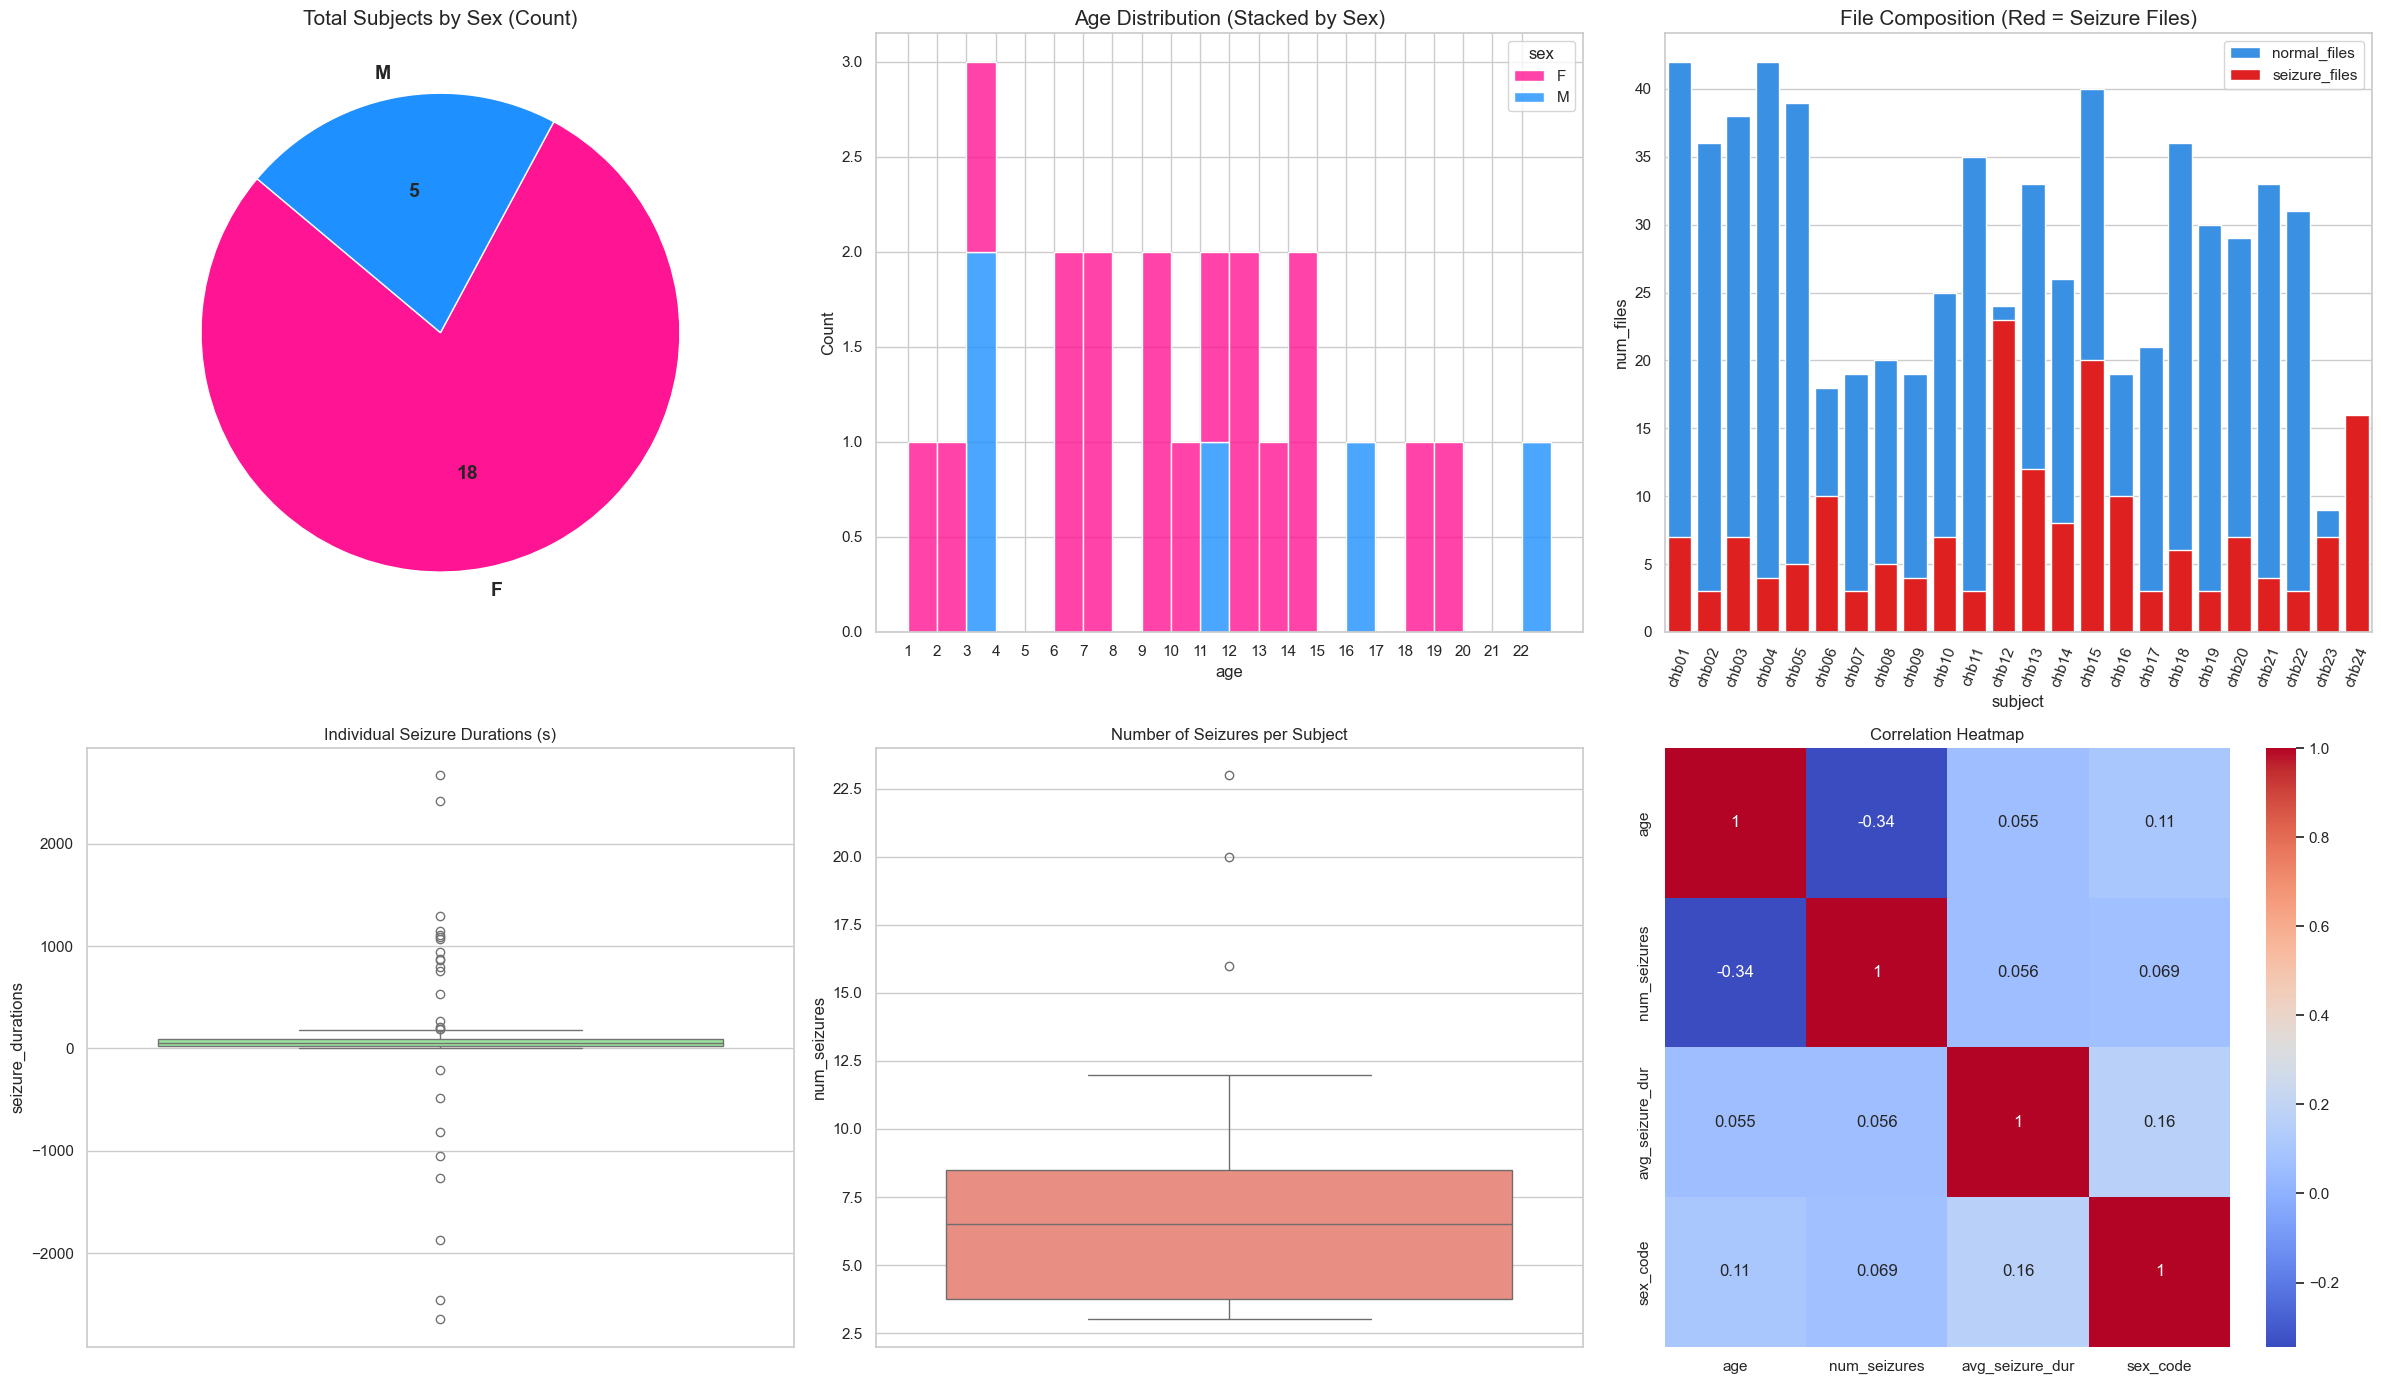

In [112]:
show_info(df_info, save=SAVE, save_path=PATH_SAVE_PLOTS)

> The dataset is **quite biased**, with more females than males subjects and the age distribution is quite the same, we've about 1/2 subjects for each age (only age 3 has 3 subjects), covering an age range from 1.5 to 22 years old. The **seizure duration present a lot of outliers between all the patients**, even if all the patients have a median seizure duration of around 55 seconds, some patients have seizures that last more than 1000 seconds, and some strange duration less 0 seconds. The **number of seizures per patient is quite constant**, with a median of around 6 seizures per patient, but some patients have more than 20 seizures. From the Correlation Heatmap is interesting notice how the **Age and Number of Seizures are negatively correlated, meaning that older a person is, less seizures they have**. From the same plot we can also notice that the **gender seems to influence the Average Seizure Duration, since females are 0 and males 1, the duration increase slightly in males** even if the males subjects are less than the females one.

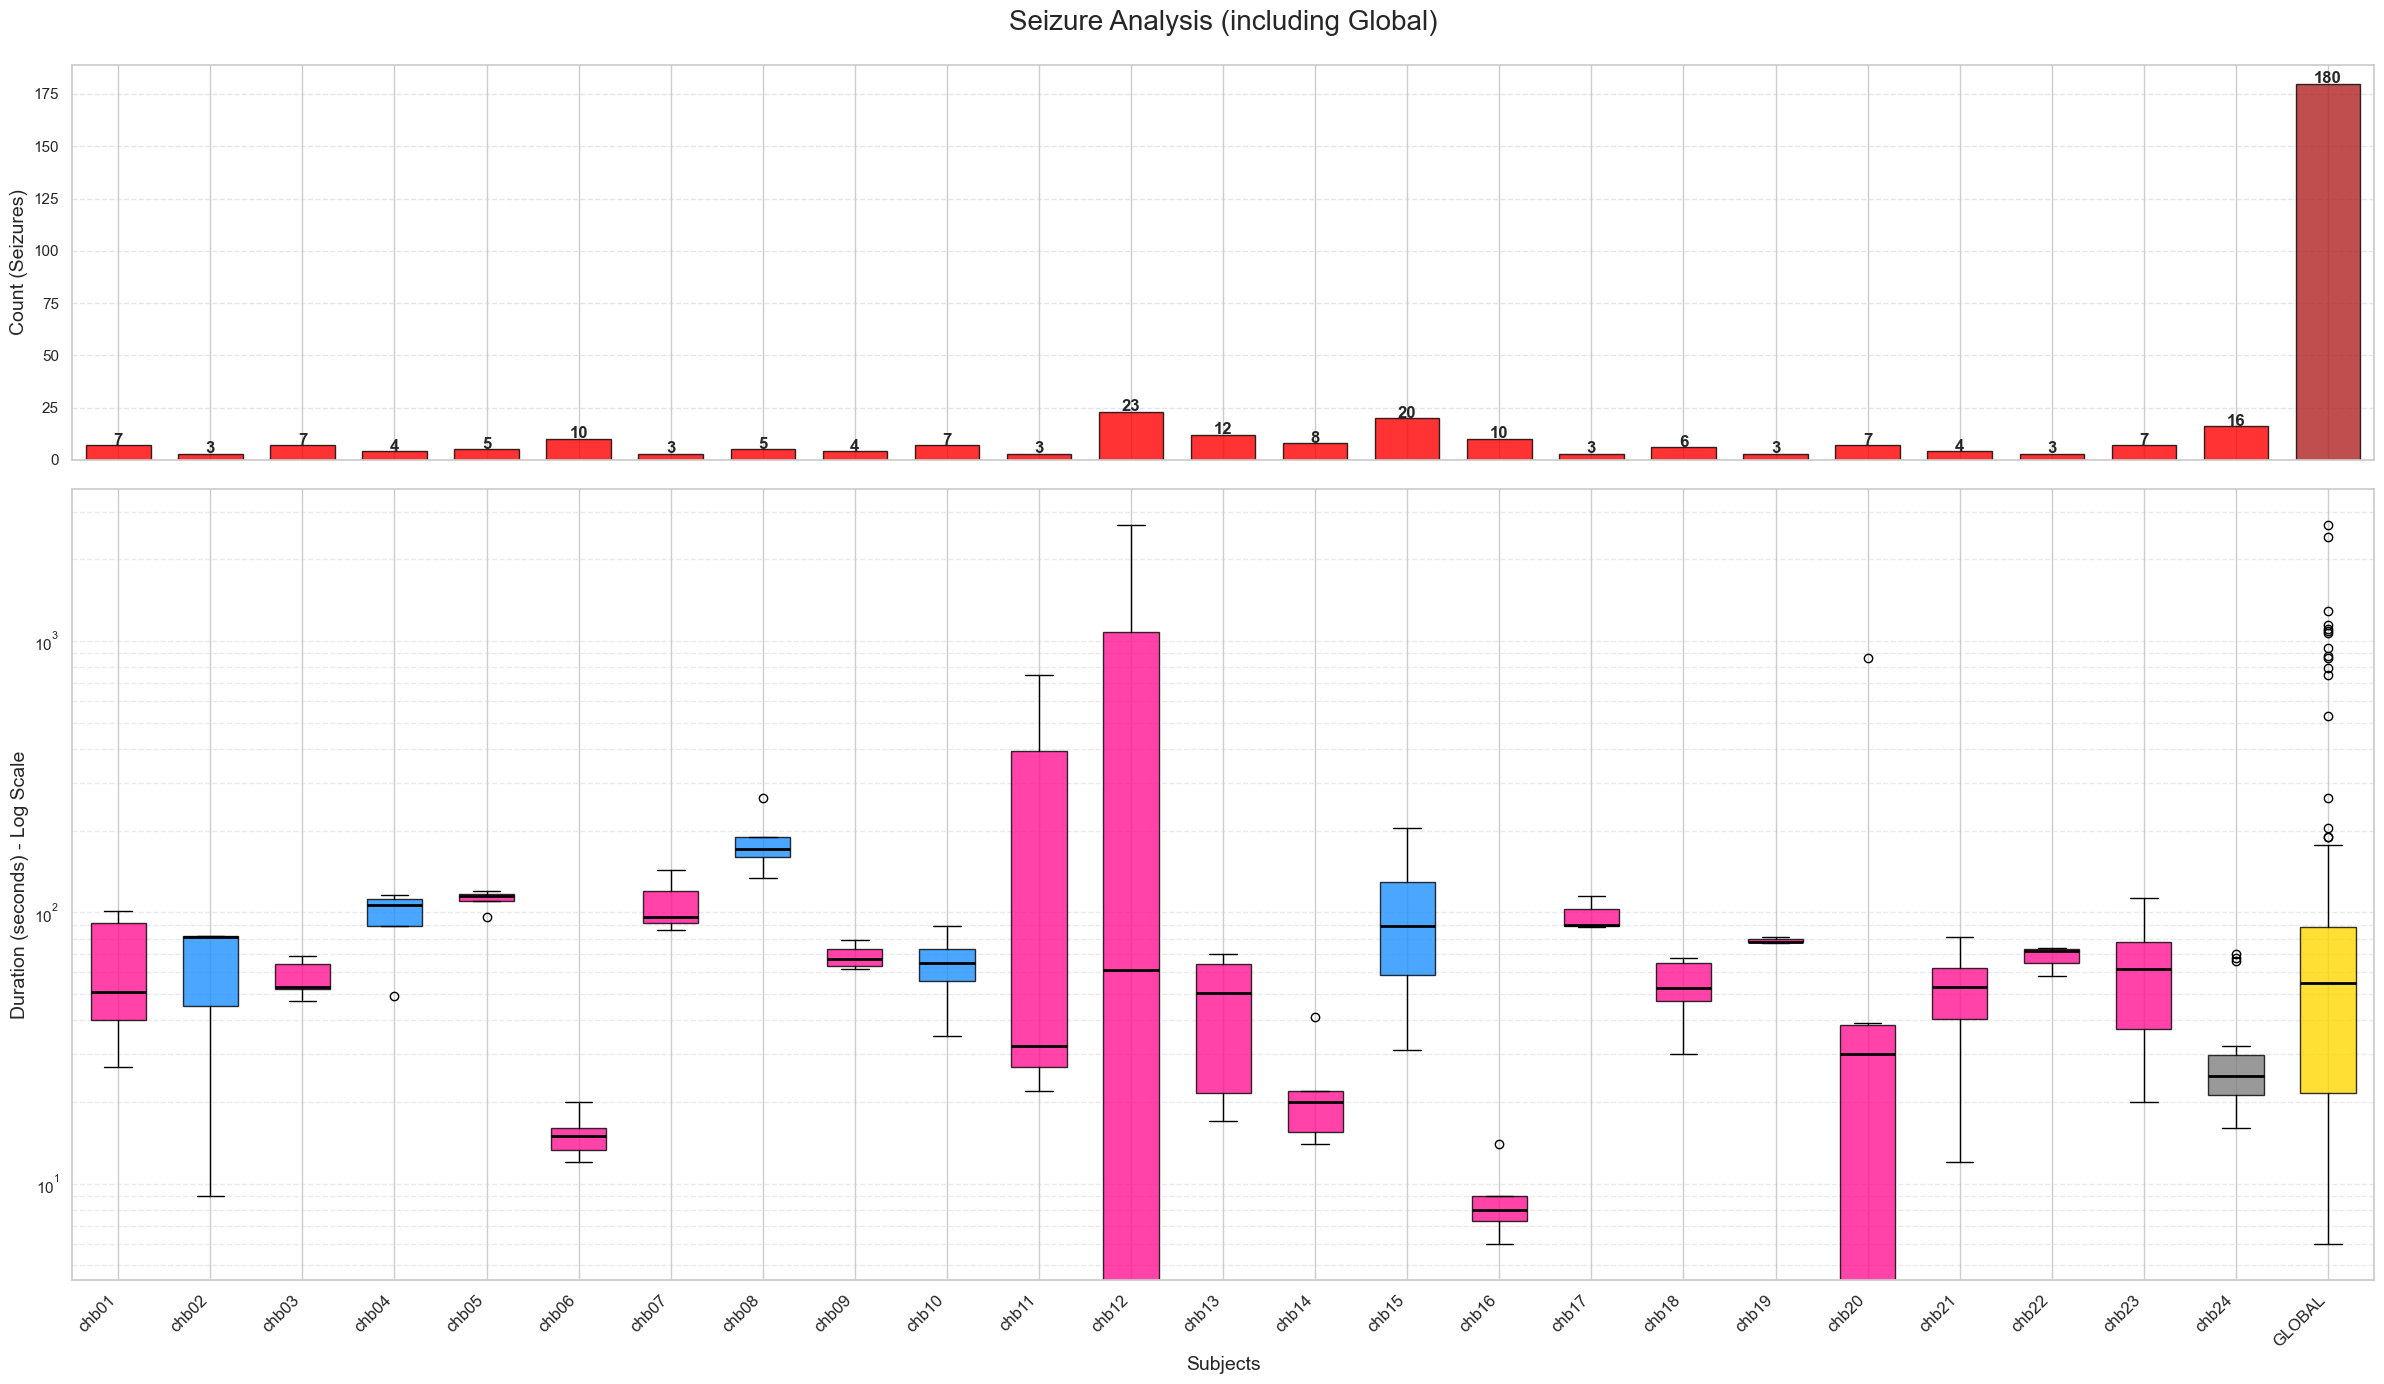

In [113]:
show_seizure_analysis(df_info, show_global=True, log_scale=True, save=SAVE, save_path=PATH_SAVE_PLOTS)

> To make the data selection process more intentional, we focused on seizure information. We used a log scale to visualize the data more clearly and to allow for an easier comparison between individual patients and the global seizure duration. The data shows that **seizure duration is highly individual**; some patients experience much longer seizures than others, a factor that is also influenced by the total number of seizures recorded for each person.

## Record Retrieval and Selection
Instead of using the whole dataset, we select specific patients based on the meta-analysis (due the significant time to download them from the site, about 1.30h for each `.edf ` file). For each patient, we keep all files containing seizures and a subset of seizure-free files (maintaining a specific ratio where non-seizure time is greater than seizure time). This selection contains both seizure and non-seizure data, which is crucial for training effective classification models. The selected records are organized and stored in a structured format for subsequent preprocessing and analysis steps.


> We decided to select four subjects based on our analysis of seizure durations. We excluded patient 24 because of missing demographic data (age and sex), even though this was the only patient with simultaneous ECG recordings. Our selection was based on age, sex, and seizure patterns:

- ***Subject 12*** was chosen because they have the highest number of recorded seizures and a duration profile that closely matches the global average, making them a key representative of the overall dataset.

- Since Subject 12 is a 2-year-old female, we paired her with ***Subject 13***, another girl of a similar age (3 years old).

- To ensure diversity in our sample, we also selected two older patients: ***Subject 4***, a 22-year-old male, and ***Subject 19***, a 19-year-old female.

In [114]:
patient_ids_selected = [4, 13, 19, 12]

In [115]:
for patient_id in patient_ids_selected:
    collect_rec_of(patient_id, non_seizure_limit=0)
    print()

[-] Patient chb04: Found 3 seizure files and 39 normal files.
[-] Selected 3 files for download (Limit non-seizure: 0).
[!] File chb04_05.edf already exists. Skipping...
[!] File chb04_08.edf already exists. Skipping...
[!] File chb04_28.edf already exists. Skipping...

[-] Patient chb13: Found 8 seizure files and 25 normal files.
[-] Selected 8 files for download (Limit non-seizure: 0).
[!] File chb13_19.edf already exists. Skipping...
[!] File chb13_21.edf already exists. Skipping...
[!] File chb13_40.edf already exists. Skipping...
[!] File chb13_55.edf already exists. Skipping...
[!] File chb13_58.edf already exists. Skipping...
[!] File chb13_59.edf already exists. Skipping...
[!] File chb13_60.edf already exists. Skipping...
[!] File chb13_62.edf already exists. Skipping...

[-] Patient chb19: Found 3 seizure files and 27 normal files.
[-] Selected 3 files for download (Limit non-seizure: 0).
[!] File chb19_28.edf already exists. Skipping...
[!] File chb19_29.edf already exists. 

In [116]:
formatted_ids = [f"chb{str(pid).zfill(2)}" for pid in patient_ids_selected]
df_info_selected = df_info[df_info['subject'].isin(formatted_ids)].copy()
display(df_info_selected)

,subject,sampling_freq,num_seizures,seizure_durations,avg_seizure_dur,min_seizure_dur,max_seizure_dur,num_files,sex,age
3,chb04,256,4,"[49.0, 111.0, 102.0, 116.0]",94.500000,49.0,116.0,42,M,22
11,chb12,256,23,"[61.0, 32.0, 13.0, 23.0, 20.0, 26.0, -2457.0, ...",220.173913,-2647.0,2668.0,24,F,2
12,chb13,256,12,"[44.0, 70.0, 31.0, 64.0, 20.0, 18.0, 17.0, 62....",44.583333,17.0,70.0,33,F,3
18,chb19,256,3,"[78.0, 77.0, 81.0]",78.666667,77.0,81.0,30,F,19


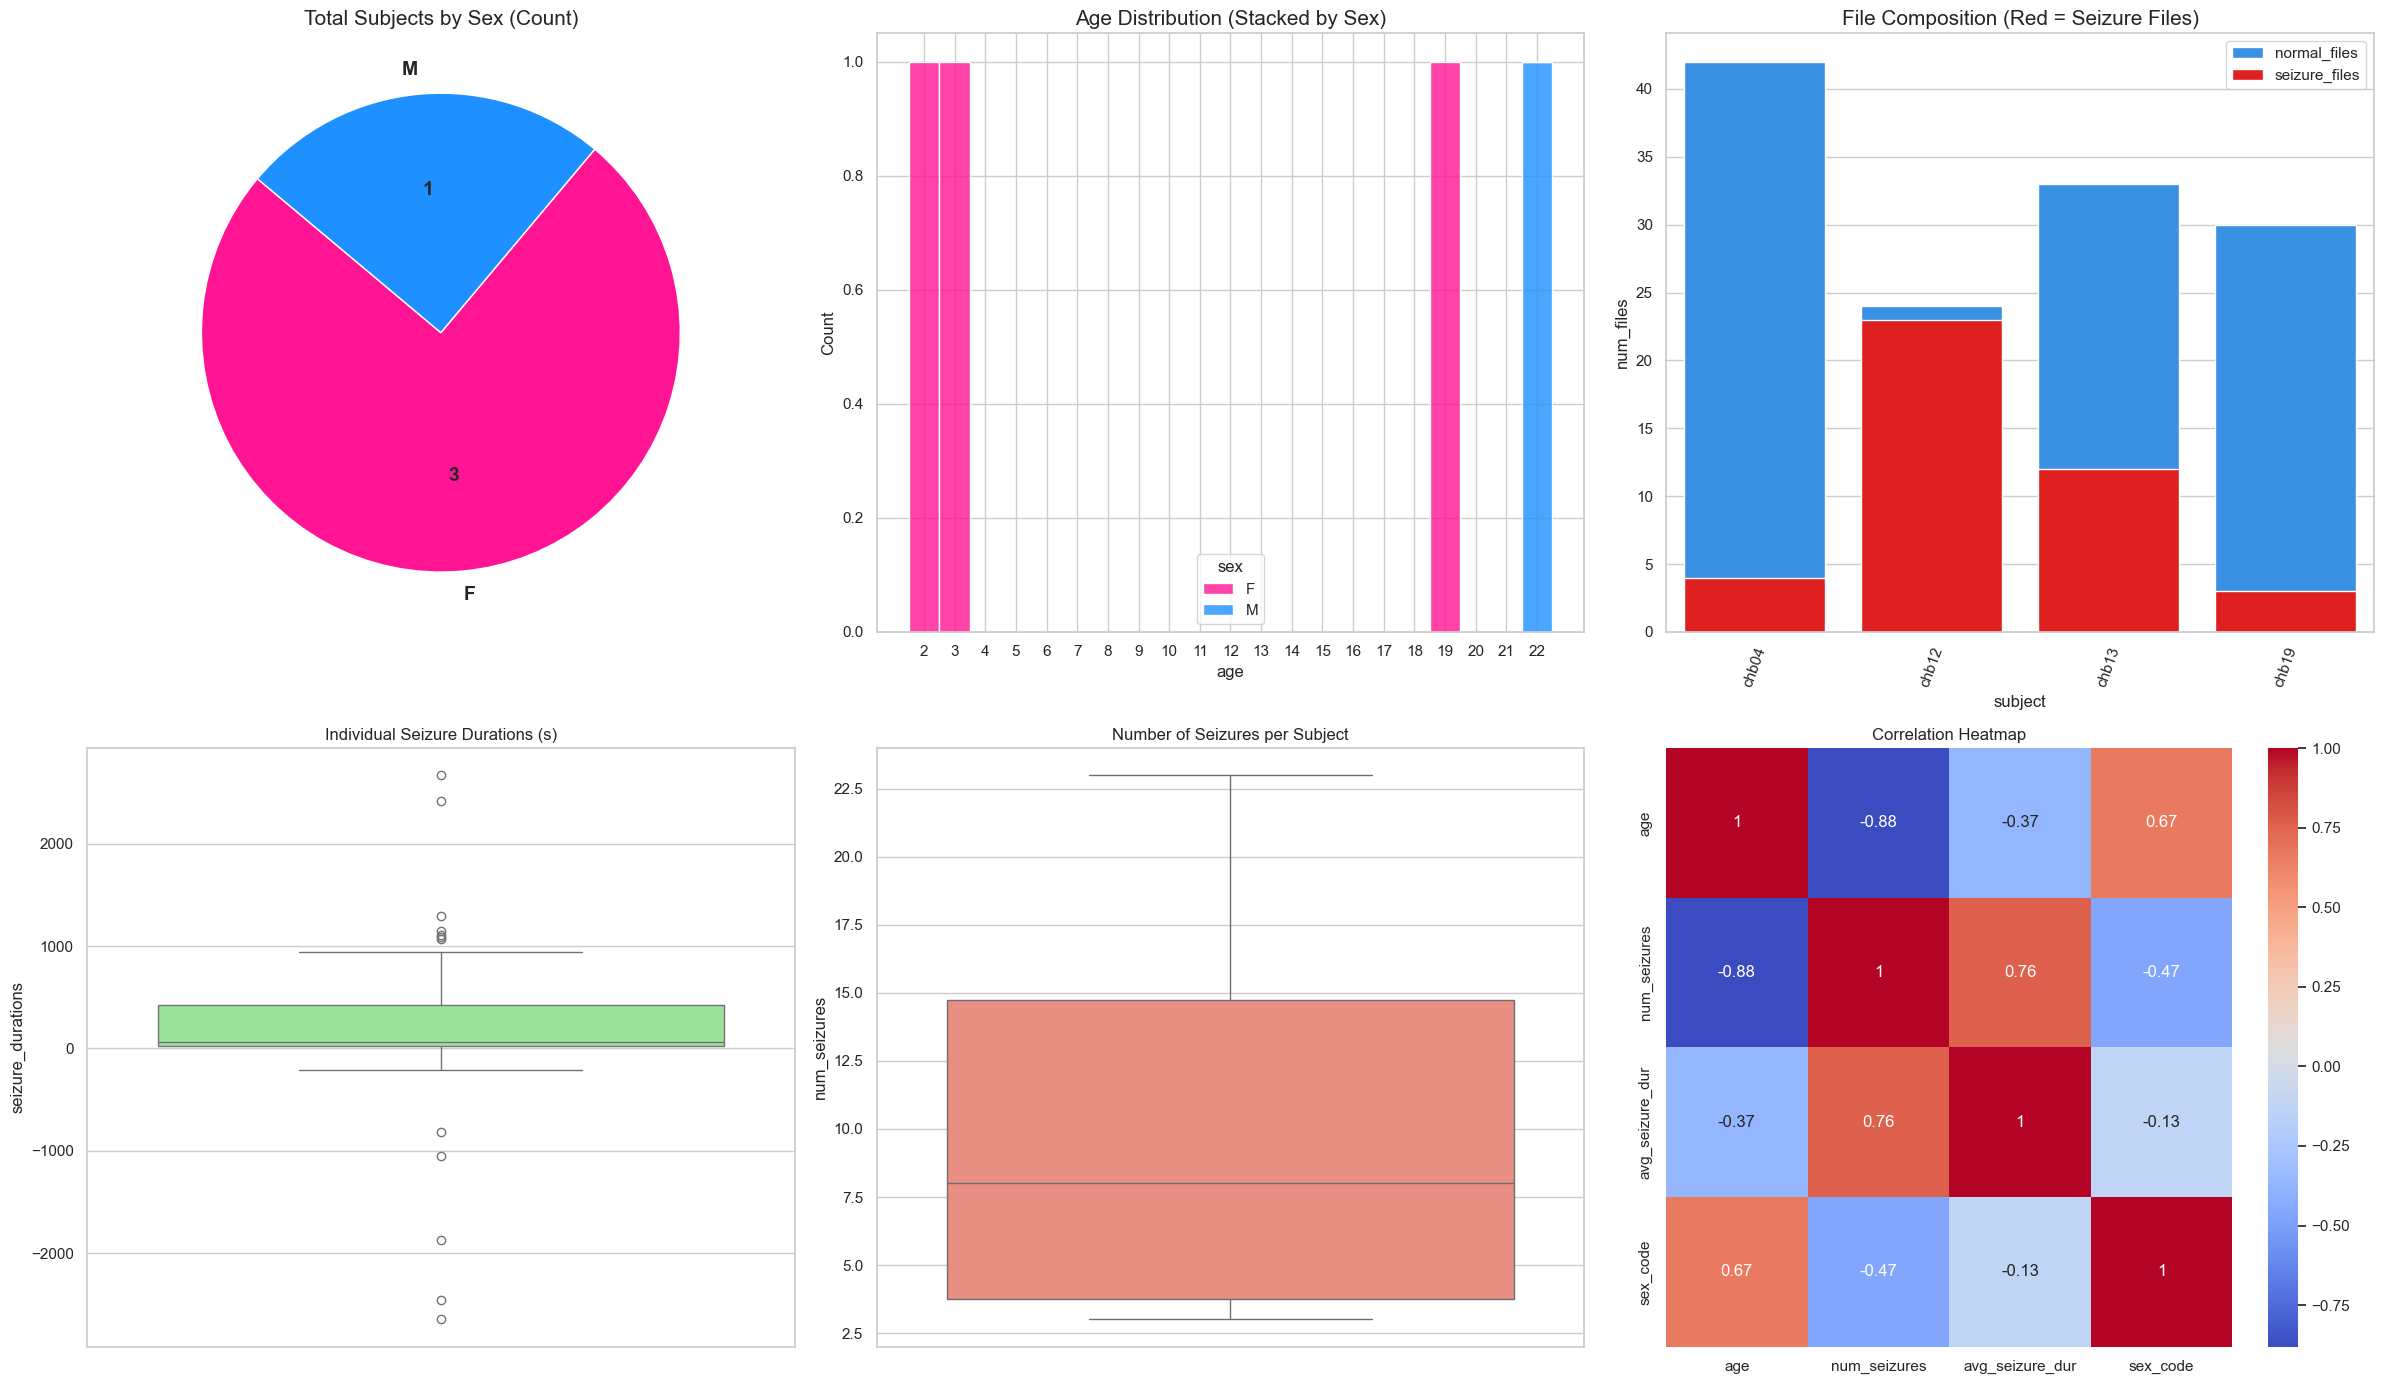

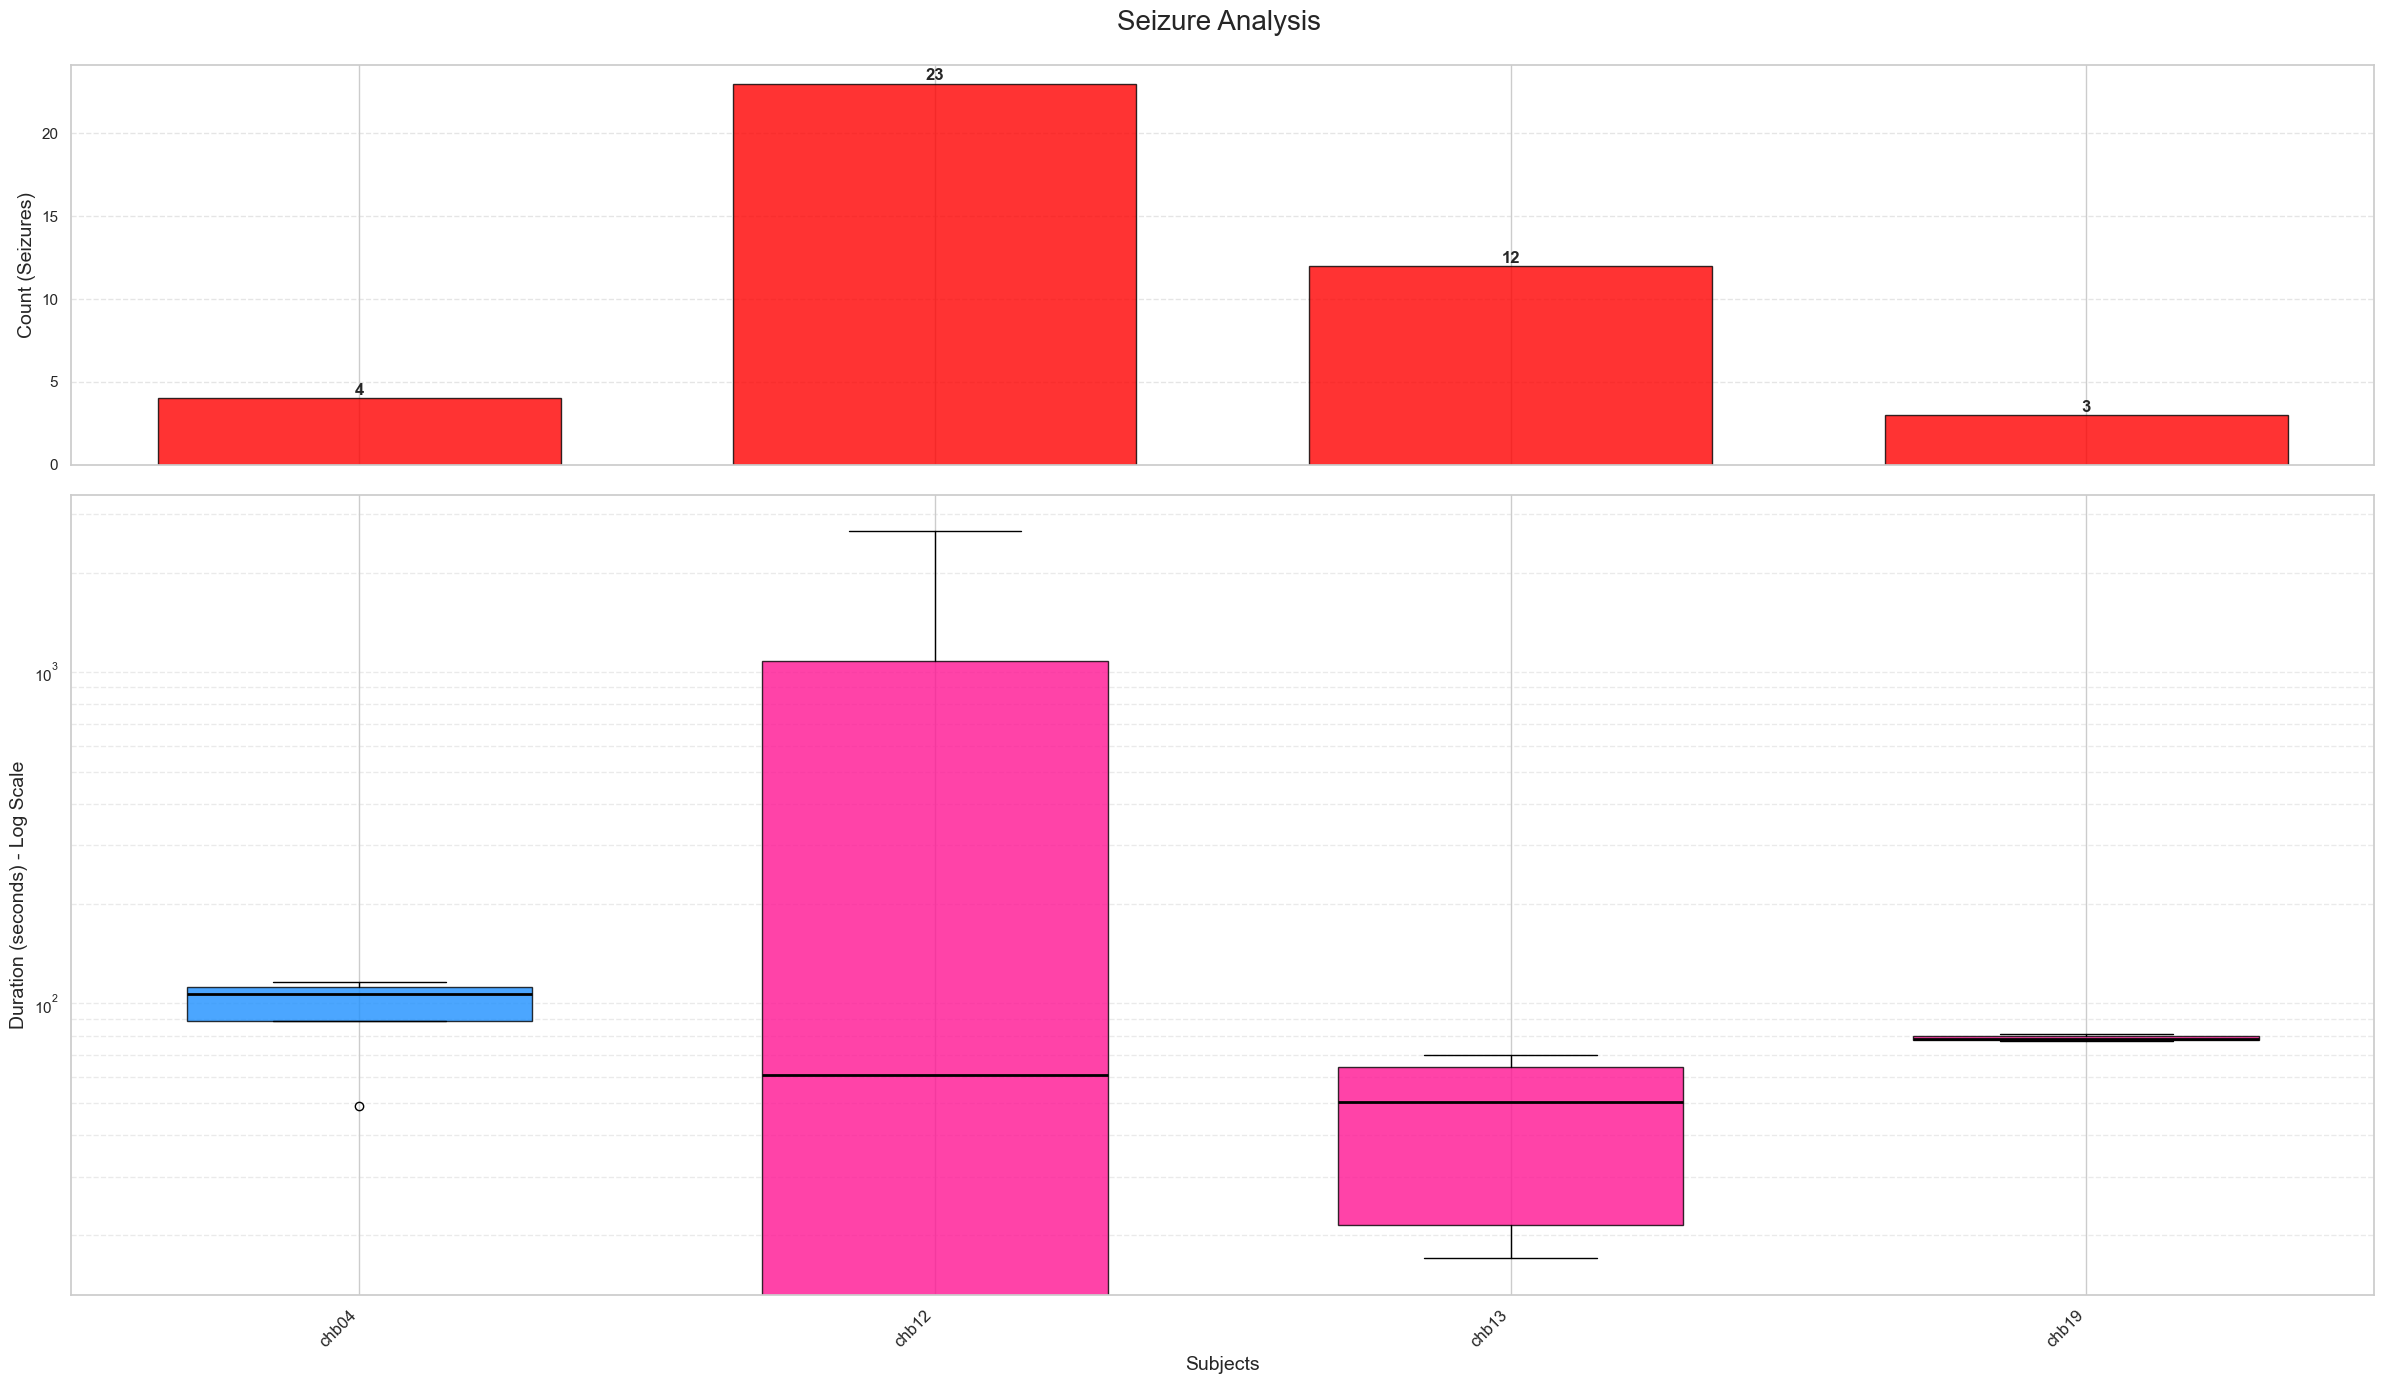

In [117]:
show_info(df_info_selected)
show_seizure_analysis(df_info_selected, log_scale=True, show_global=False)


 CLINICAL PROFILE: CHB04
 DEMOGRAPHICS
 ├─ Age: 22
 └─ Sex: M

 DATASET STATS
 ├─ Total EEG Records:  42
 ├─ Est. Total Time:    ~151200 hours
 └─ Sampling Frequency: 256 Hz

 SEIZURE ANALYSIS
 ├─ Total Seizures:     4
 ├─ Total Seizure Time: 378.0s (~6.30 min)
 ├─ Average Duration:   94.50s
 ├─ Min/Max Duration:   49.0s / 116.0s
 └─ Seizure Burden:     0.105 hours of ictal activity
                        0.25% of total recording



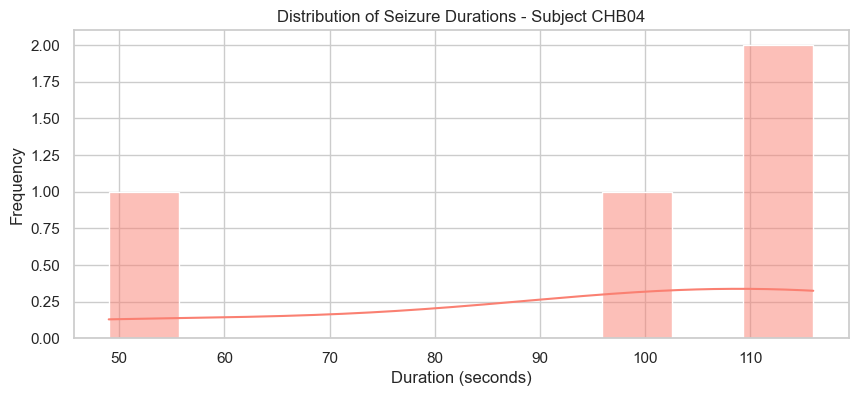

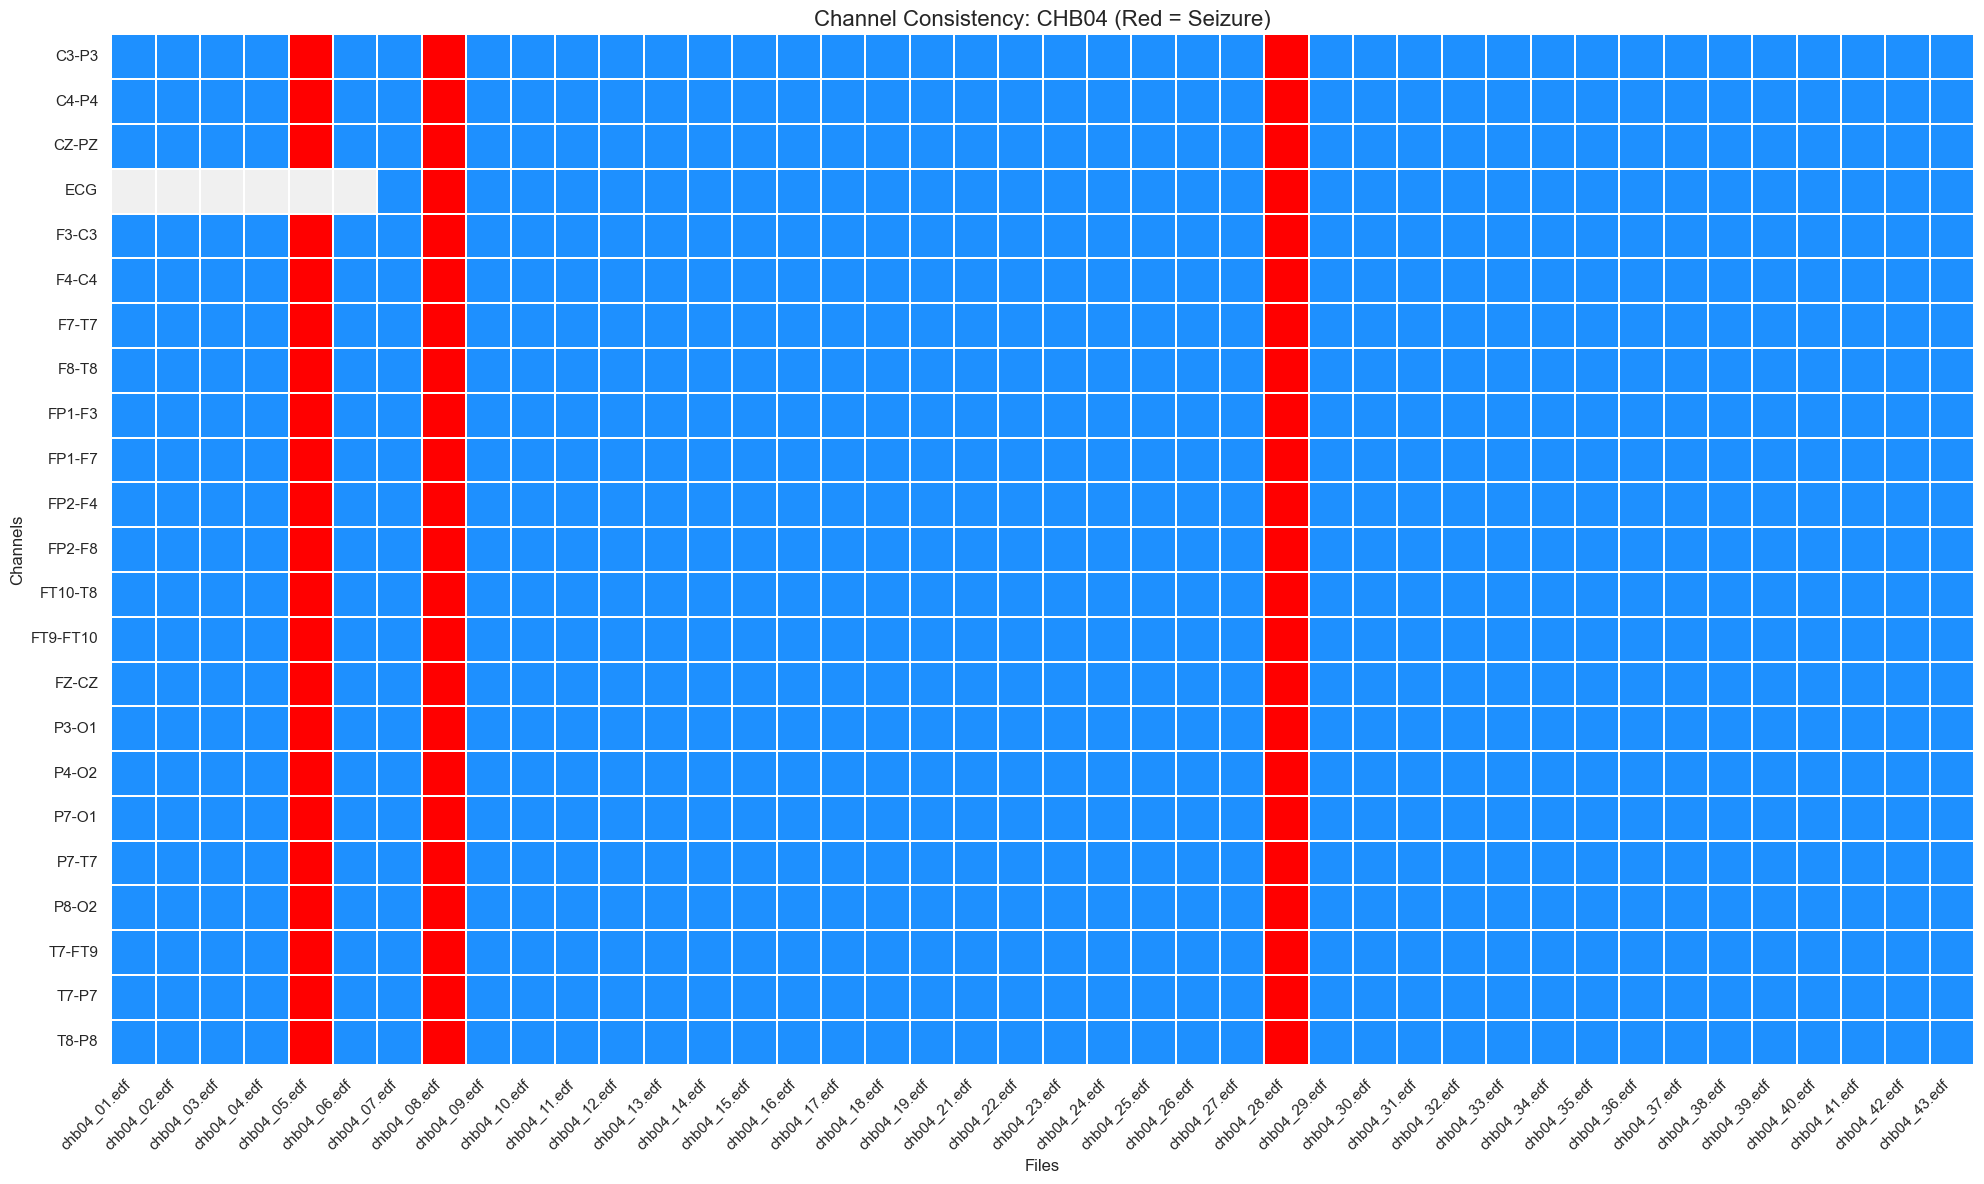


 CLINICAL PROFILE: CHB13
 DEMOGRAPHICS
 ├─ Age:  3
 └─ Sex: F

 DATASET STATS
 ├─ Total EEG Records:  33
 ├─ Est. Total Time:    ~118800 hours
 └─ Sampling Frequency: 256 Hz

 SEIZURE ANALYSIS
 ├─ Total Seizures:     12
 ├─ Total Seizure Time: 535.0s (~8.92 min)
 ├─ Average Duration:   44.58s
 ├─ Min/Max Duration:   17.0s / 70.0s
 └─ Seizure Burden:     0.149 hours of ictal activity
                        0.45% of total recording



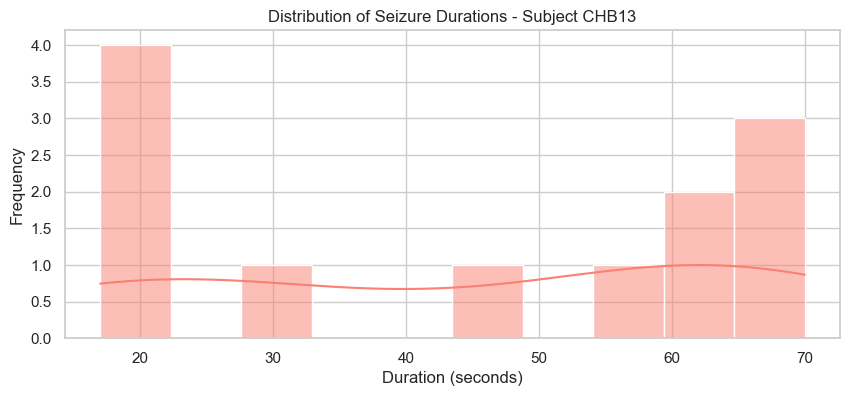

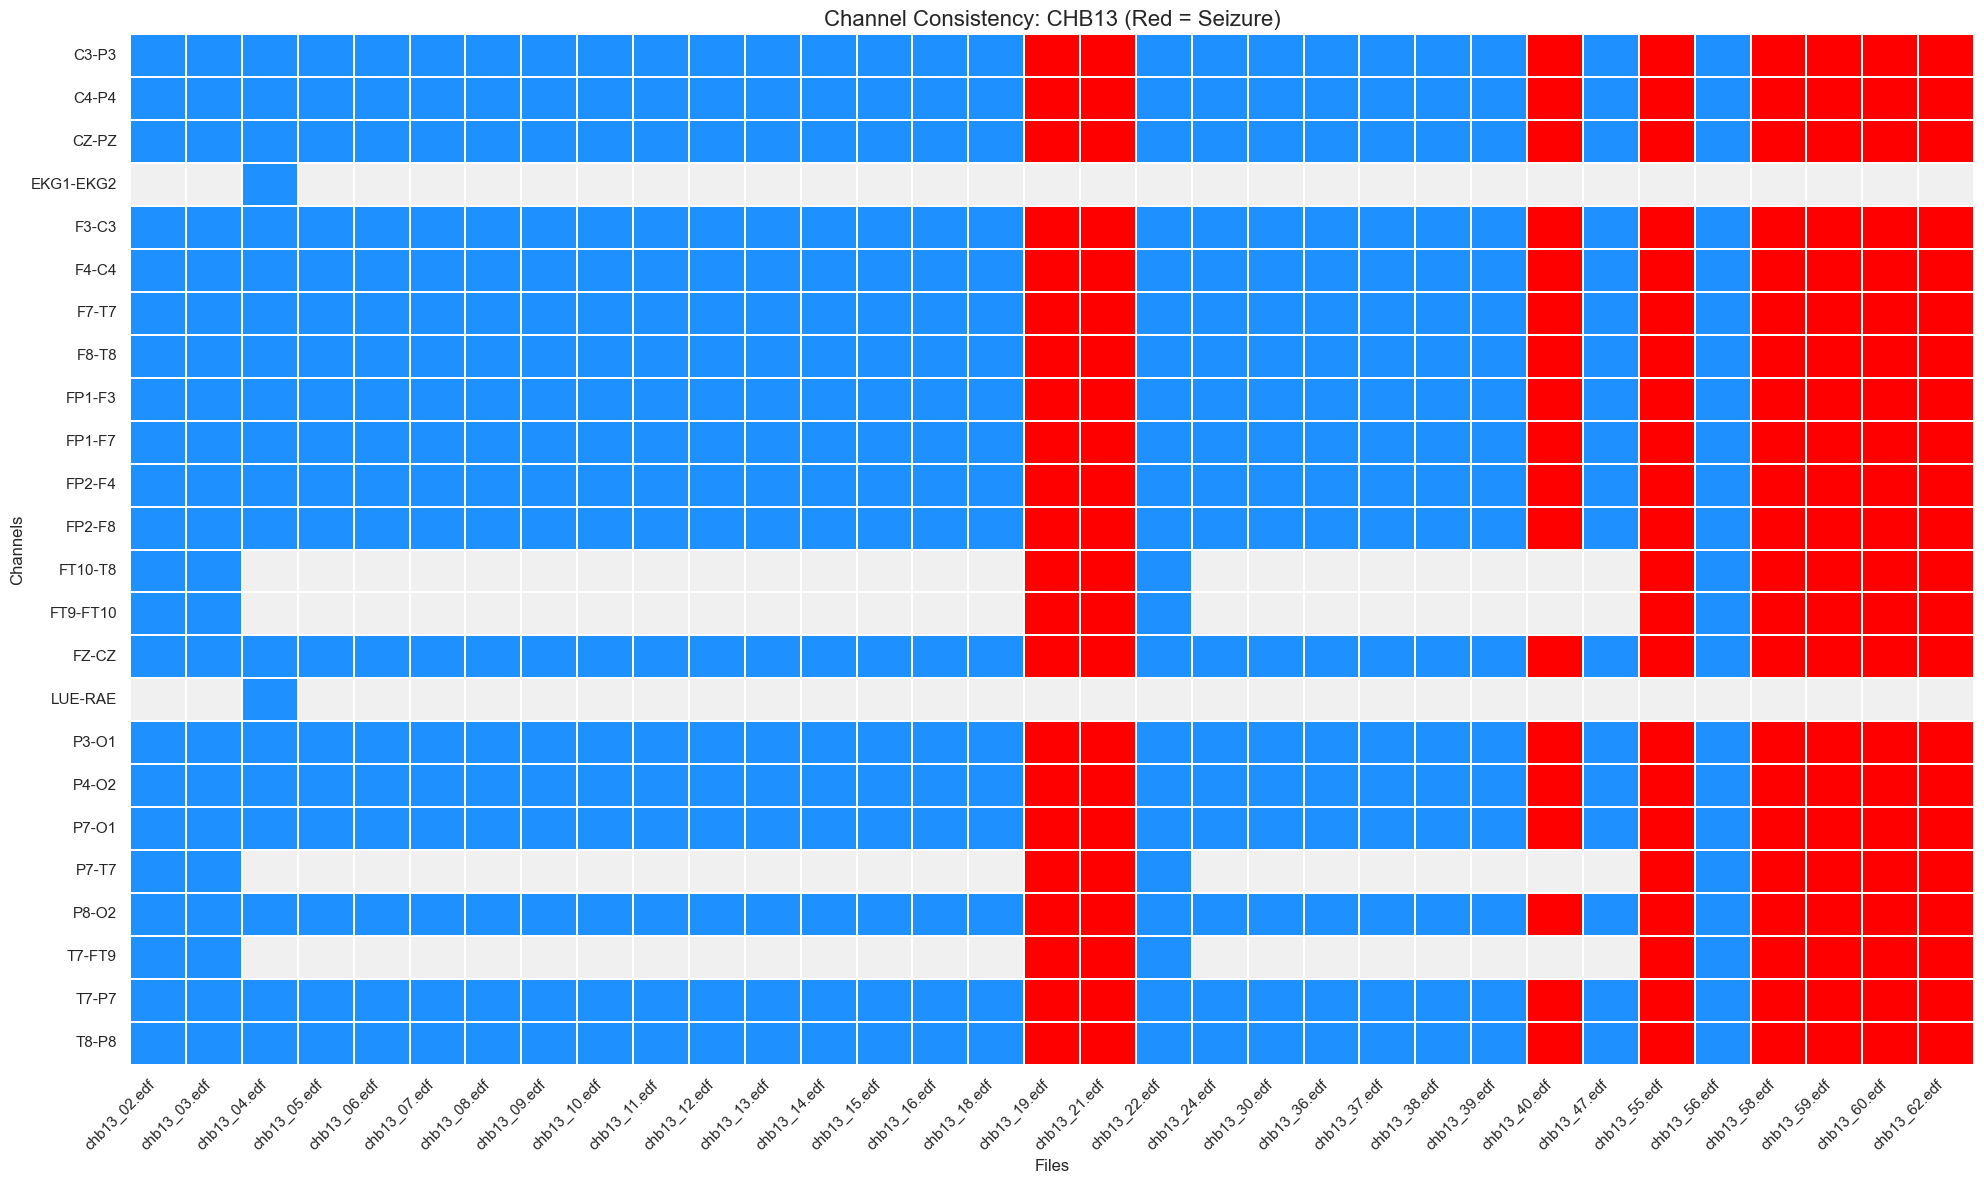


 CLINICAL PROFILE: CHB19
 DEMOGRAPHICS
 ├─ Age: 19
 └─ Sex: F

 DATASET STATS
 ├─ Total EEG Records:  30
 ├─ Est. Total Time:    ~108000 hours
 └─ Sampling Frequency: 256 Hz

 SEIZURE ANALYSIS
 ├─ Total Seizures:     3
 ├─ Total Seizure Time: 236.0s (~3.93 min)
 ├─ Average Duration:   78.67s
 ├─ Min/Max Duration:   77.0s / 81.0s
 └─ Seizure Burden:     0.066 hours of ictal activity
                        0.22% of total recording



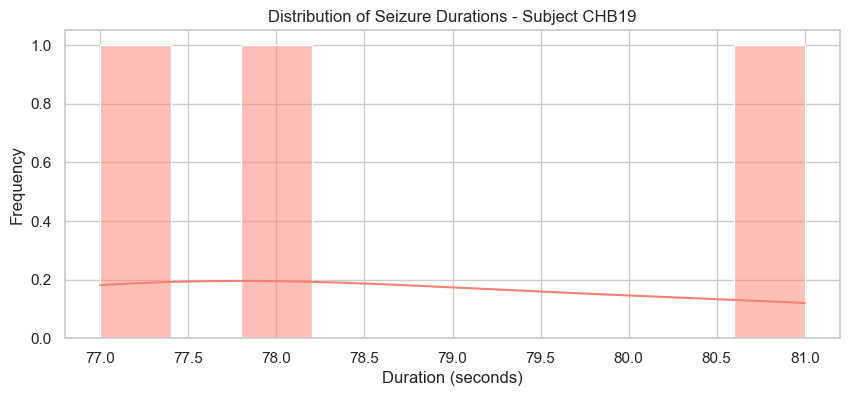

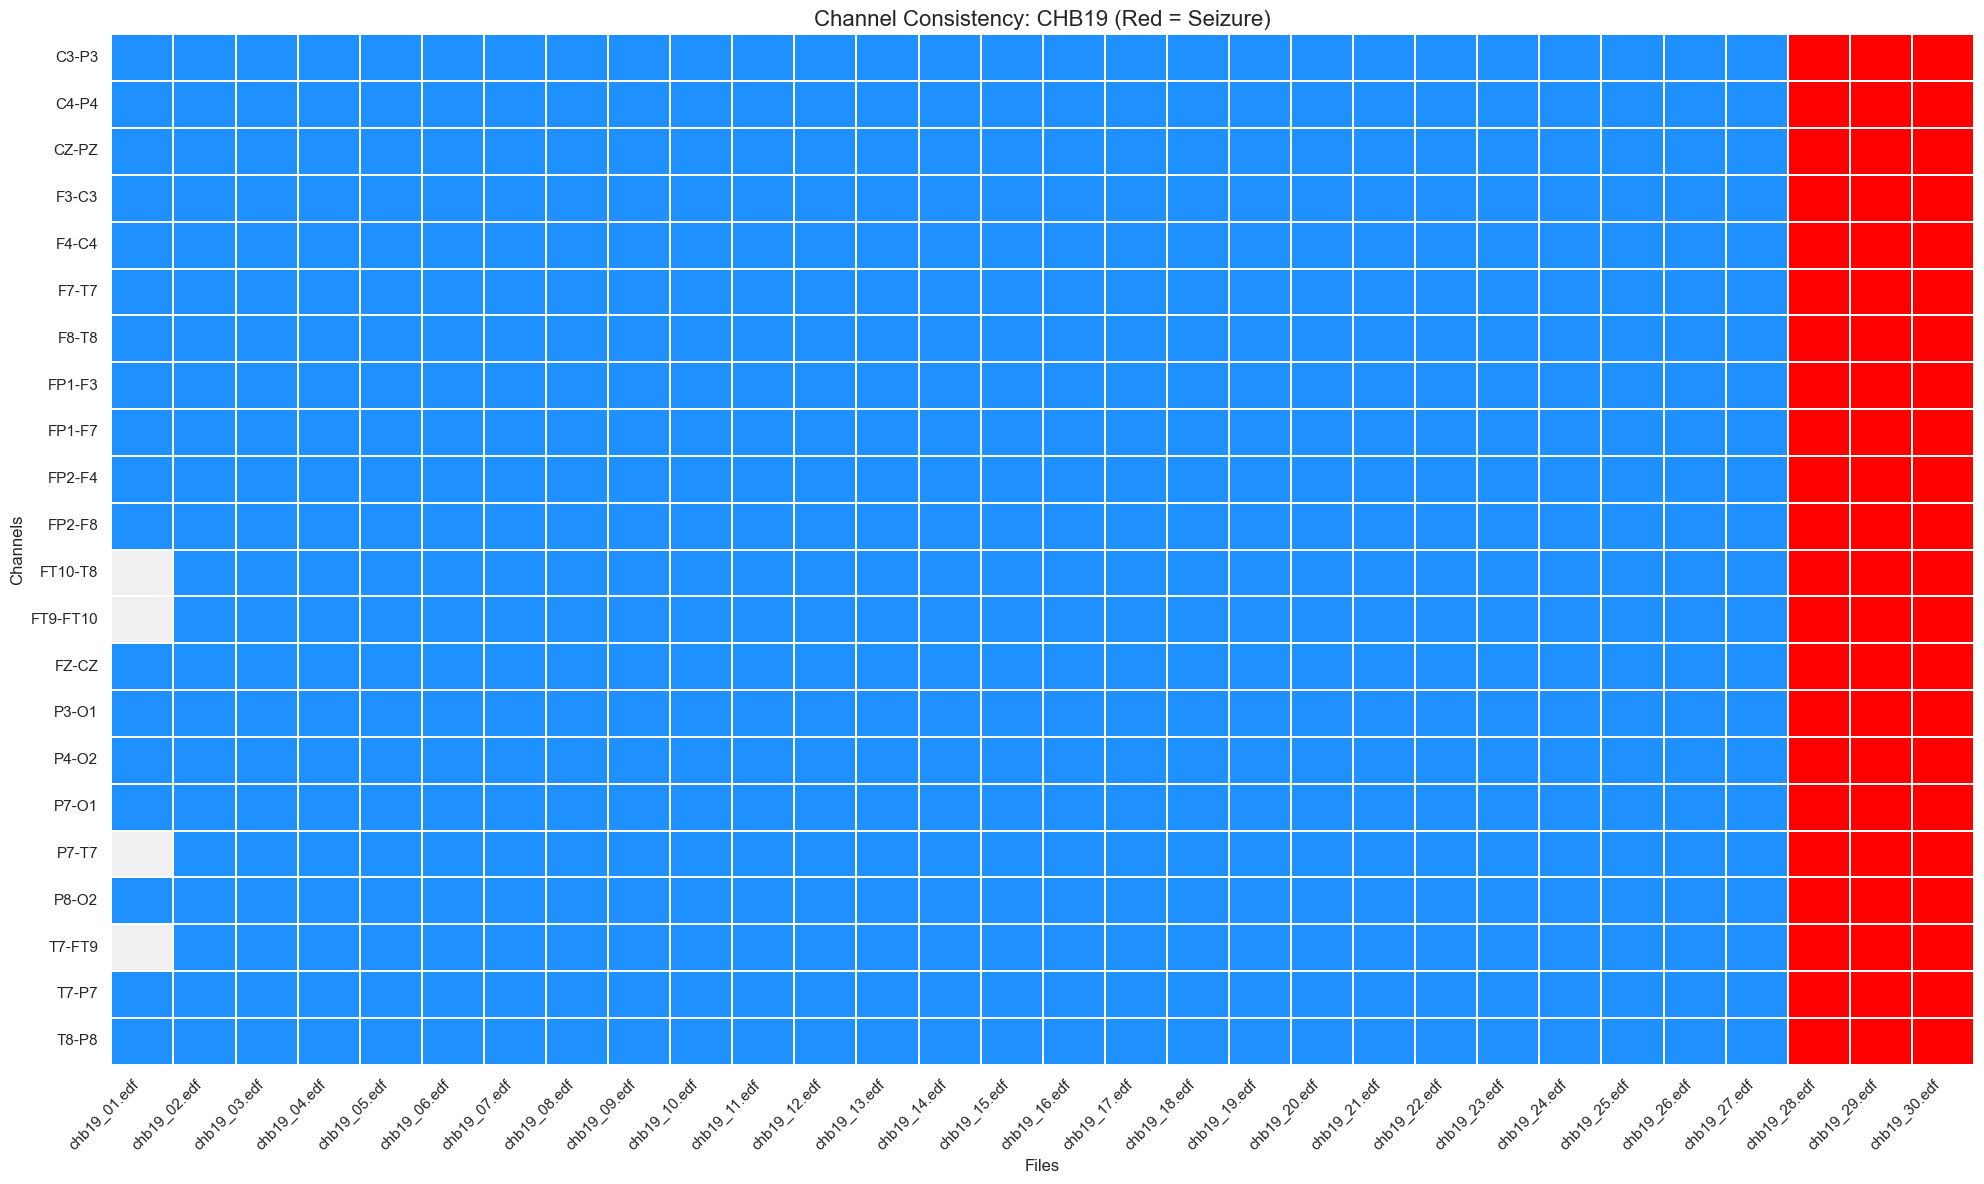


 CLINICAL PROFILE: CHB12
 DEMOGRAPHICS
 ├─ Age:  2
 └─ Sex: F

 DATASET STATS
 ├─ Total EEG Records:  24
 ├─ Est. Total Time:    ~86400 hours
 └─ Sampling Frequency: 256 Hz

 SEIZURE ANALYSIS
 ├─ Total Seizures:     23
 ├─ Total Seizure Time: 5064.0s (~84.40 min)
 ├─ Average Duration:   220.17s
 ├─ Min/Max Duration:   -2647.0s / 2668.0s
 └─ Seizure Burden:     1.407 hours of ictal activity
                        5.86% of total recording



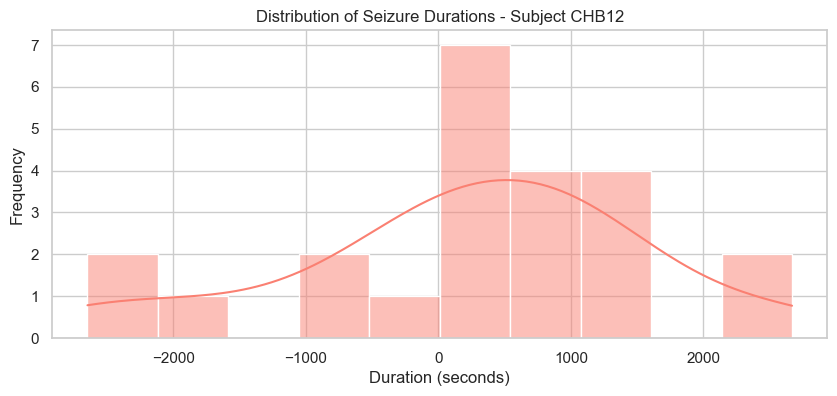

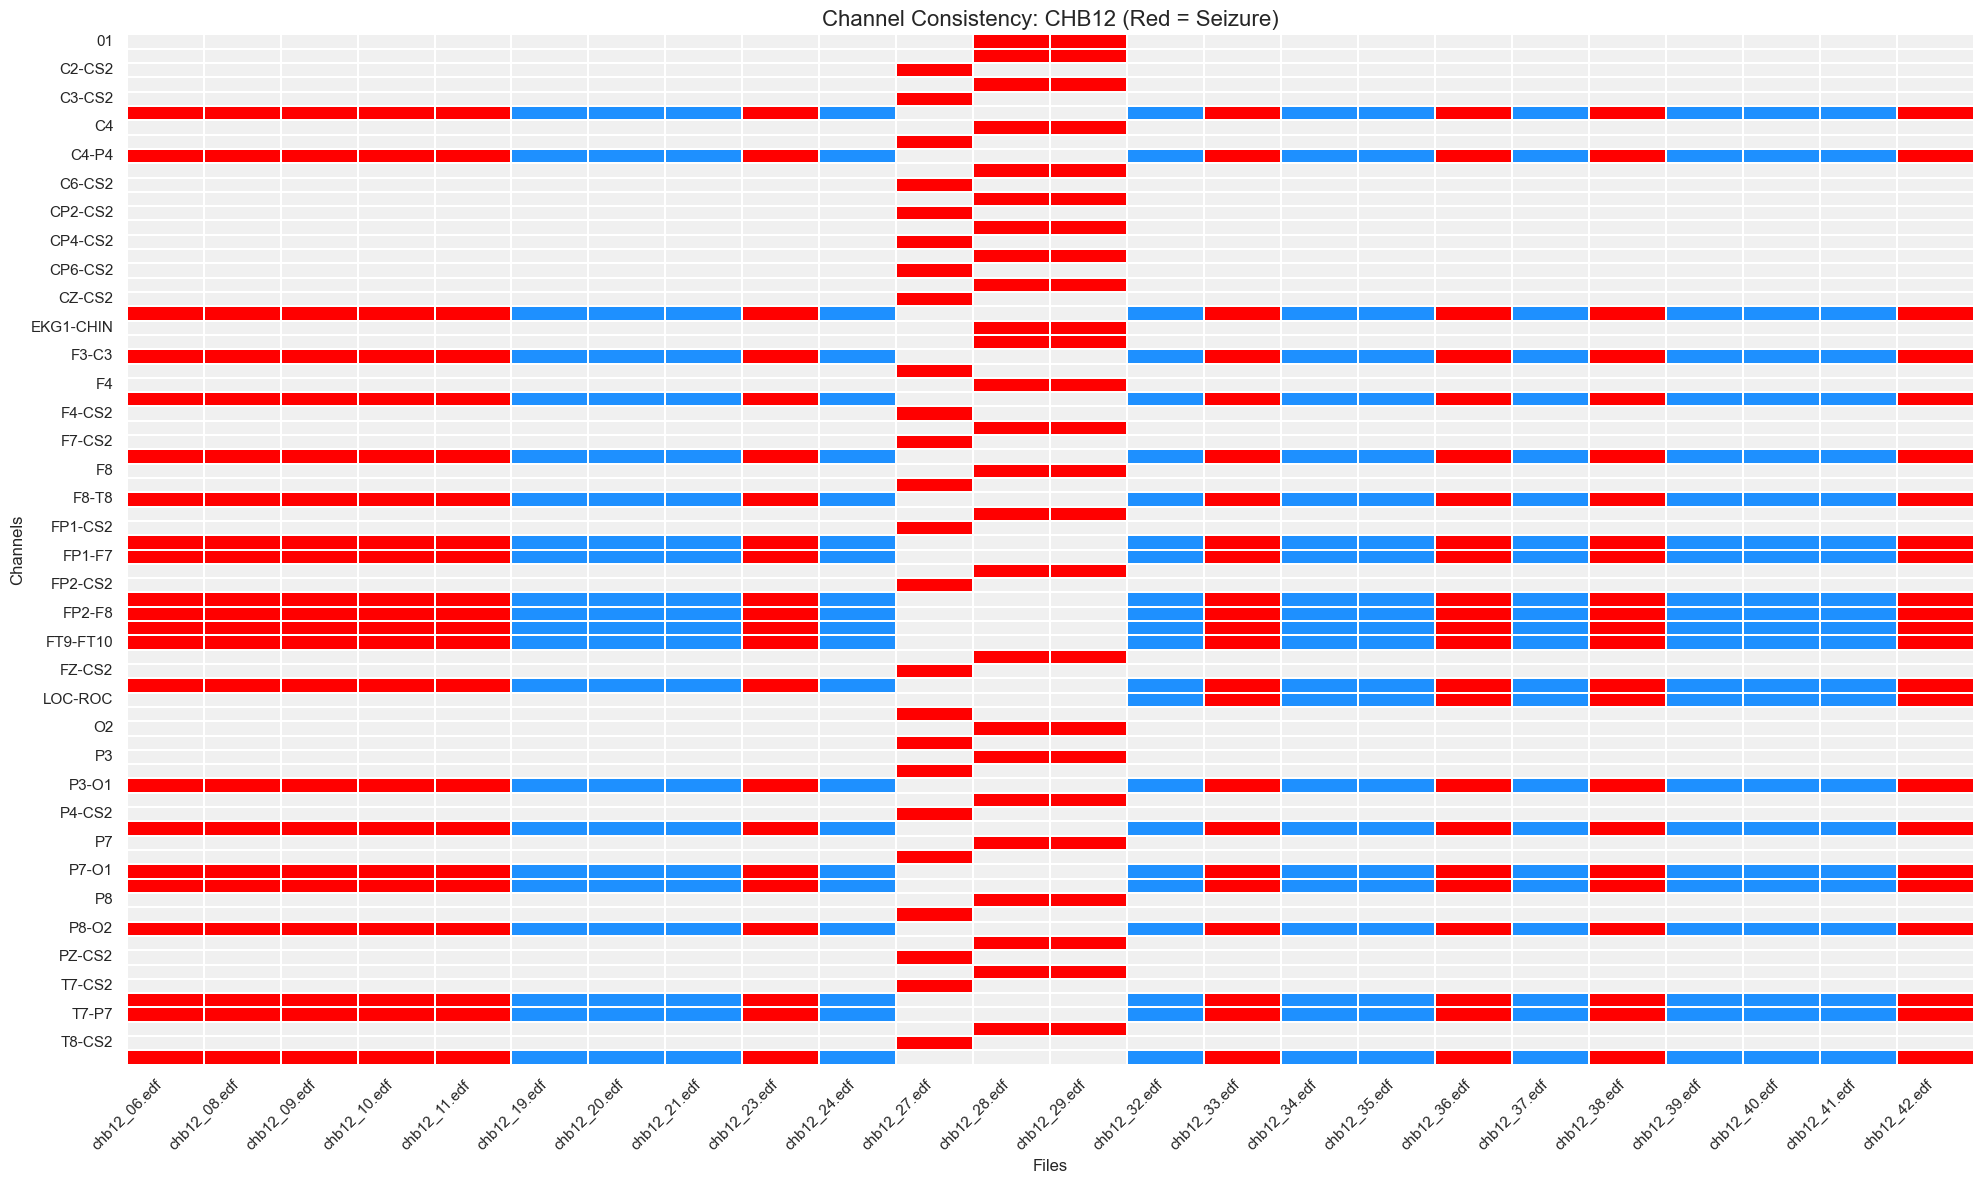

In [141]:
for patient_id in patient_ids_selected:
    show_info_of_patient(df_info, patient_id)
    plot_channel_availability_from_summary( patient_id, RAW_INFO_PATH, filter_downloaded=False, raw_records_path=RAW_RECORDS_PATH, verbose=False,)
